# DDPM — Chequeo de métricas físicas (Kaggle / T4)

**Objetivo**: vistazo rápido para verificar que las métricas físicas de `metrics.py` funcionan bien sobre imágenes generadas por el **DDPM** (único modelo en este cuadernillo).

**Protocolo estadístico**:
- Se muestrean `N` conjuntos de parámetros θ del **split de test** (SEED=42, 70/15/15), estratificados por **fase magnética** (6 fases, proporcional a su frecuencia en el test).
- Por cada θ se generan `K` imágenes desde el DDPM (muestreo estocástico del ruido inicial).
- Cada métrica se calcula **por muestra** (gen_i vs original) y luego se promedia sobre las K — nunca se promedian las imágenes.
- Resultados **generales** y **por fase**.

**Config inicial**: `N=2000`, `K=4`. Calibrado para correr en ~20–35 min en una T4.

**Inputs (Kaggle datasets)**:
- `carloscanamejoy/dataset-spines-united-v2` → `dataset_unificado_v2.npz`
- `carloscanamejoy/weights-models` → `ddpm_spines_final_39crop.pt`
- `carloscanamejoy/physicalmetrics` → `metrics.py`

In [1]:
# ============================================================
# CONFIGURACIÓN — edita aquí
# ============================================================
N = 2000          # nº de conjuntos de parámetros θ a evaluar (muestreados del test)
K = 4             # nº de imágenes generadas por θ (para promediar métricas)
SEED = 42         # semilla del split (debe coincidir con el entrenamiento del DDPM)
SAMPLE_SEED = 123 # semilla del muestreo estratificado y del ruido de generación
FAST_STEPS = 100  # pasos del sampler DDIM rápido
GEN_BATCH = 64    # batch de generación (imágenes simultáneas en GPU)

print(f"N={N} θ  ×  K={K} muestras  =  {N*K:,} generaciones | DDIM {FAST_STEPS} pasos")

N=2000 θ  ×  K=4 muestras  =  8,000 generaciones | DDIM 100 pasos


In [2]:
# ============================================================
# Setup: imports y localización de archivos (Kaggle o Colab)
# ============================================================
import os, sys, time, math, importlib.util
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__} | device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

def _find(candidates, what):
    for p in candidates:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"No encuentro {what}. Probé: {candidates}")

DATASET_PATH = "/kaggle/input/datasets/carloscanamejoy/dataset-spines-united-v2/dataset_unificado_v2.npz"

DDPM_CKPT = "/kaggle/input/datasets/carloscanamejoy/weights-models/ddpm_spines_final_39crop.pt"

METRICS_PATH = "/kaggle/input/datasets/carloscanamejoy/physicalmetrics/metrics.py"

print(f"dataset: {DATASET_PATH}")
print(f"ddpm:    {DDPM_CKPT}")
print(f"metrics: {METRICS_PATH}")

PyTorch 2.10.0+cu128 | device: cuda
GPU: Tesla T4
dataset: /kaggle/input/datasets/carloscanamejoy/dataset-spines-united-v2/dataset_unificado_v2.npz
ddpm:    /kaggle/input/datasets/carloscanamejoy/weights-models/ddpm_spines_final_39crop.pt
metrics: /kaggle/input/datasets/carloscanamejoy/physicalmetrics/metrics.py


In [3]:
# ============================================================
# Cargar metrics.py compartido
# ============================================================
spec = importlib.util.spec_from_file_location("metrics", METRICS_PATH)
metrics = importlib.util.module_from_spec(spec)
spec.loader.exec_module(metrics)
sys.modules["metrics"] = metrics

from metrics import (
    STRUCTURE_MAP, STRUCTURE_NAMES, STRUCTURE_COLORS, MASK,
    get_structure_label,
    masked_ssim, masked_mse,
    magnetization, abs_magnetization, cnn_correlation,
    structure_factor, azimuthal_average, oz_fit,
    center_crop, apply_figure_style,
)
apply_figure_style()
print("metrics.py cargado.")
print(f"Fases ({len(STRUCTURE_NAMES)}): {STRUCTURE_NAMES}")

metrics.py cargado.
Fases (6): ['Ferromagnetic', 'Helical', 'Labyrinthine & Conical', 'Bimeron', 'Skyrmions', 'Field-Saturated']


In [4]:
# ============================================================
# Cargar dataset y reconstruir el split de test (SEED=42, 100%)
# Réplica EXACTA de make_split() del notebook de entrenamiento del DDPM:
#   - subsample 100% con rng.choice(SEED)
#   - split 70/15/15 con train_test_split(random_state=SEED)
#   - MinMaxScaler ajustado SOLO en train
# Esto reproduce el mismo test set y el mismo scaler que vio el DDPM.
# ============================================================
data   = np.load(DATASET_PATH)
imgs   = data["img"].astype(np.float32)
params = data["params"].astype(np.float32)
labels = data["labels"].astype(int)
if imgs.ndim == 3:
    imgs = imgs[..., np.newaxis]
Nfull = len(imgs)
print(f"dataset: {imgs.shape}  params {params.shape}  | clusters {sorted(np.unique(labels).tolist())}")

rng = np.random.RandomState(SEED)
sub_idx = rng.choice(Nfull, size=int(Nfull * 1.0), replace=False)   # 100%

idx_all = np.arange(len(sub_idx))
idx_tr, idx_tmp = train_test_split(idx_all, test_size=0.30, random_state=SEED)
idx_va, idx_te  = train_test_split(idx_tmp, test_size=0.50, random_state=SEED)

scaler = MinMaxScaler().fit(params[sub_idx][idx_tr])

# Índices globales del test set + sus etiquetas y fase
test_global = sub_idx[idx_te]
test_imgs   = imgs[test_global]                         # 39×39 (originales)
test_params = params[test_global]
test_phase  = np.array([get_structure_label(c) for c in labels[test_global]])
print(f"test set: {len(test_global):,} muestras")

# Distribución de fases en el test
print("\nDistribución de fases en el test:")
for ph in STRUCTURE_NAMES:
    cnt = int((test_phase == ph).sum())
    print(f"  {ph:24s} {cnt:6,}  ({100*cnt/len(test_phase):5.1f}%)")

dataset: (169671, 39, 39, 1)  params (169671, 8)  | clusters [4, 5, 6, 8, 10, 11, 12, 13, 14, 15, 16, 17]
test set: 25,451 muestras

Distribución de fases en el test:
  Ferromagnetic             3,886  ( 15.3%)
  Helical                  15,206  ( 59.7%)
  Labyrinthine & Conical    2,918  ( 11.5%)
  Bimeron                     921  (  3.6%)
  Skyrmions                 1,562  (  6.1%)
  Field-Saturated             958  (  3.8%)


In [5]:
# ============================================================
# Muestreo estratificado por fase: cuota proporcional a la
# frecuencia de cada fase en el test. Ej.: si Helical es 32%
# del test y N=2000 → ~640 muestras Helical.
# ============================================================
samp_rng = np.random.RandomState(SAMPLE_SEED)
sel_local = []
for ph in STRUCTURE_NAMES:
    ph_idx = np.where(test_phase == ph)[0]
    if len(ph_idx) == 0:
        continue
    quota = int(round(N * len(ph_idx) / len(test_phase)))
    quota = min(quota, len(ph_idx))                      # no exceder lo disponible
    if quota > 0:
        sel_local.append(samp_rng.choice(ph_idx, size=quota, replace=False))
sel_local = np.concatenate(sel_local)
samp_rng.shuffle(sel_local)

eval_imgs   = test_imgs[sel_local]                       # (N, 39, 39, 1)
eval_params = test_params[sel_local]                     # (N, 8) físicos
eval_phase  = test_phase[sel_local]                      # (N,)
eval_cond   = scaler.transform(eval_params).astype(np.float32)  # θ normalizado para el DDPM

print(f"Seleccionadas {len(sel_local):,} θ (objetivo N={N}). Reparto real por fase:")
for ph in STRUCTURE_NAMES:
    print(f"  {ph:24s} {int((eval_phase==ph).sum()):5,}")

Seleccionadas 1,999 θ (objetivo N=2000). Reparto real por fase:
  Ferromagnetic              305
  Helical                  1,195
  Labyrinthine & Conical     229
  Bimeron                     72
  Skyrmions                  123
  Field-Saturated             75


In [6]:
# ============================================================
# Arquitectura del DDPM (idéntica a ddpm_spines_train.ipynb)
# ============================================================
IMG_SIZE = 40
CROP_TO  = 39
COND_DIM = 8
T_STEPS  = 1000  # FIX: scheduler de entrenamiento es T=1000; el sampler DDIM usa FAST_STEPS=100 sobre esos 1000
BETA_START, BETA_END = 1e-4, 0.02

class DDPMScheduler:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, schedule='cosine', device='cpu'):
        self.T = T
        if schedule == 'linear':
            betas = torch.linspace(beta_start, beta_end, T, device=device)
        elif schedule == 'cosine':
            steps = T + 1; s = 0.008
            x = torch.linspace(0, T, steps, device=device)
            ac = torch.cos(((x / T) + s) / (1 + s) * math.pi * 0.5) ** 2
            ac = ac / ac[0]
            betas = (1 - (ac[1:] / ac[:-1])).clamp(max=0.999)
        else:
            raise ValueError(schedule)
        alphas = 1.0 - betas
        ac = torch.cumprod(alphas, dim=0)
        self.sqrt_alphas_cumprod = ac.sqrt()
        self.sqrt_one_minus_alphas_cumprod = (1.0 - ac).sqrt()
        self.betas = betas; self.alphas = alphas; self.alphas_cumprod = ac

def sinusoidal_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device).float() / (half - 1))
    args = t[:, None].float() * freqs[None]
    return torch.cat([args.sin(), args.cos()], dim=-1)

class TimeCondEmbedding(nn.Module):
    def __init__(self, t_dim, cond_in, out_dim):
        super().__init__()
        self.t_mlp = nn.Sequential(nn.Linear(t_dim, out_dim), nn.SiLU(), nn.Linear(out_dim, out_dim))
        self.c_mlp = nn.Sequential(nn.Linear(cond_in, out_dim), nn.SiLU(), nn.Linear(out_dim, out_dim))
    def forward(self, t, cond):
        t_emb = sinusoidal_embedding(t, self.t_mlp[0].in_features)
        return self.t_mlp(t_emb) + self.c_mlp(cond)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim, groups=8, dropout=0.0):
        super().__init__()
        self.norm1 = nn.GroupNorm(groups, in_ch); self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(groups, out_ch); self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, emb):
        h = F.silu(self.norm1(x)); h = self.conv1(h)
        h = h + self.emb_proj(F.silu(emb))[:, :, None, None]
        h = F.silu(self.norm2(h)); h = self.dropout(h); h = self.conv2(h)
        return h + self.skip(x)

class SelfAttention(nn.Module):
    def __init__(self, ch, groups=8):
        super().__init__()
        self.norm = nn.GroupNorm(groups, ch); self.qkv = nn.Conv2d(ch, ch*3, 1); self.proj = nn.Conv2d(ch, ch, 1)
    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x); q, k, v = self.qkv(h).chunk(3, dim=1)
        q = q.reshape(B, C, -1); k = k.reshape(B, C, -1); v = v.reshape(B, C, -1)
        attn = torch.softmax(torch.bmm(q.transpose(1, 2), k) / math.sqrt(C), dim=-1)
        out = torch.bmm(v, attn.transpose(1, 2)).reshape(B, C, H, W)
        return x + self.proj(out)

class ConditionalUNet(nn.Module):
    def __init__(self, img_channels=1, base_ch=64, ch_mults=(1, 2, 4), cond_dim=8, emb_dim=128, dropout=0.0):
        super().__init__()
        chs = [base_ch * m for m in ch_mults]
        self.emb = TimeCondEmbedding(t_dim=emb_dim, cond_in=cond_dim, out_dim=emb_dim)
        self.conv_in = nn.Conv2d(img_channels, chs[0], 3, padding=1)
        self.down_blocks = nn.ModuleList(); self.down_samples = nn.ModuleList()
        in_ch = chs[0]; self.skip_channels = []
        for i, out_ch in enumerate(chs):
            self.down_blocks.append(nn.ModuleList([
                ResBlock(in_ch, out_ch, emb_dim, dropout=dropout),
                ResBlock(out_ch, out_ch, emb_dim, dropout=dropout)]))
            self.skip_channels.append(out_ch)
            self.down_samples.append(nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1) if i < len(chs)-1 else nn.Identity())
            in_ch = out_ch
        self.mid_block1 = ResBlock(chs[-1], chs[-1], emb_dim, dropout=dropout)
        self.mid_attn = SelfAttention(chs[-1])
        self.mid_block2 = ResBlock(chs[-1], chs[-1], emb_dim, dropout=dropout)
        self.up_blocks = nn.ModuleList(); self.up_samples = nn.ModuleList()
        for i, out_ch in enumerate(reversed(chs)):
            skip_ch = self.skip_channels[-(i + 1)]
            self.up_blocks.append(nn.ModuleList([
                ResBlock(in_ch + skip_ch, out_ch, emb_dim, dropout=dropout),
                ResBlock(out_ch, out_ch, emb_dim, dropout=dropout)]))
            self.up_samples.append(nn.ConvTranspose2d(out_ch, out_ch, 4, stride=2, padding=1) if i < len(chs)-1 else nn.Identity())
            in_ch = out_ch
        self.norm_out = nn.GroupNorm(8, chs[0]); self.conv_out = nn.Conv2d(chs[0], img_channels, 1)
    def forward(self, x, t, cond):
        emb = self.emb(t, cond); h = self.conv_in(x); skips = []
        for (rb1, rb2), ds in zip(self.down_blocks, self.down_samples):
            h = rb1(h, emb); h = rb2(h, emb); skips.append(h); h = ds(h)
        h = self.mid_block1(h, emb); h = self.mid_attn(h); h = self.mid_block2(h, emb)
        for (rb1, rb2), us, skip in zip(self.up_blocks, self.up_samples, reversed(skips)):
            h = torch.cat([h, skip], dim=1); h = rb1(h, emb); h = rb2(h, emb); h = us(h)
        h = F.silu(self.norm_out(h))
        return self.conv_out(h)

@torch.no_grad()
def fast_sample(model, cond, scheduler, n_steps=100, img_size=40):
    """Sampler DDIM determinista (idéntico al de entrenamiento)."""
    B = cond.shape[0]
    x = torch.randn(B, 1, img_size, img_size, device=cond.device)
    timesteps = list(range(0, scheduler.T, scheduler.T // n_steps))[::-1]
    for t_val in timesteps:
        t_tensor = torch.full((B,), t_val, device=cond.device, dtype=torch.long)
        eps_pred = model(x, t_tensor, cond)
        sqrt_a = scheduler.sqrt_alphas_cumprod[t_val]
        sqrt_1a = scheduler.sqrt_one_minus_alphas_cumprod[t_val]
        x0_pred = ((x - sqrt_1a * eps_pred) / sqrt_a).clamp(-1, 1)
        if t_val > 0:
            t_prev = max(t_val - scheduler.T // n_steps, 0)
            sqrt_a_prev = scheduler.sqrt_alphas_cumprod[t_prev]
            sqrt_1a_prev = scheduler.sqrt_one_minus_alphas_cumprod[t_prev]
            x = sqrt_a_prev * x0_pred + sqrt_1a_prev * eps_pred
        else:
            x = x0_pred
    return x

print("Arquitectura DDPM definida.")

Arquitectura DDPM definida.


In [7]:
# ============================================================
# Cargar checkpoint DDPM (usa pesos EMA si existen)
# ============================================================
ckpt = torch.load(DDPM_CKPT, map_location=DEVICE, weights_only=False)
hp = ckpt.get("hyperparams", {"base_ch": 80, "cond_emb_dim": 128, "dropout": 0.1, "beta_schedule": "cosine"})

model = ConditionalUNet(
    img_channels=1, base_ch=hp["base_ch"], ch_mults=(1, 2, 4),
    cond_dim=COND_DIM, emb_dim=hp["cond_emb_dim"], dropout=hp["dropout"],
).to(DEVICE)

model.load_state_dict(ckpt["model"])
if ckpt.get("ema") is not None:
    print("Aplicando pesos EMA.")
    with torch.no_grad():
        for n, p in model.named_parameters():
            if p.requires_grad and n in ckpt["ema"]:
                p.data.copy_(ckpt["ema"][n].to(DEVICE))
model.eval()

scheduler = DDPMScheduler(T=T_STEPS, beta_start=BETA_START, beta_end=BETA_END,
                          schedule=hp["beta_schedule"], device=DEVICE)
print(f"DDPM cargado: {sum(p.numel() for p in model.parameters())/1e6:.1f}M params | schedule={hp['beta_schedule']}")

Aplicando pesos EMA.
DDPM cargado: 18.1M params | schedule=cosine


In [ ]:
# ============================================================
# Métricas por imagen — se guardan VALORES CRUDOS (gen y real)
# Físicas (escalares): magnetización, correlación NN, q-pico S(q), ξ (OZ).
#   → luego R²(gen vs real) sobre el conjunto.
# Imagen (similitud): mse, bce, ssim, coseno.
#   → luego se convierten a similitud 1=idéntico, 0=diferencia total.
# Todas las imágenes en [-1, 1], comparadas dentro de la máscara circular.
# ============================================================
_mask_flat = MASK.ravel()

def per_image_metrics(gen39, real39):
    """Valores crudos para una pareja (gen, real) 39x39. Coseno se añade aparte."""
    out = {}
    # --- físicas: valor en gen y en real ---
    out["mag_gen"]   = float(magnetization(gen39))
    out["mag_real"]  = float(magnetization(real39))
    out["corr_gen"]  = float(cnn_correlation(gen39))
    out["corr_real"] = float(cnn_correlation(real39))
    q_g, sq_g = azimuthal_average(structure_factor(gen39))
    q_r, sq_r = azimuthal_average(structure_factor(real39))
    out["qpeak_gen"]  = float(q_g[np.argmax(sq_g)]) if len(sq_g) else np.nan
    out["qpeak_real"] = float(q_r[np.argmax(sq_r)]) if len(sq_r) else np.nan
    _, xi_g, _ = oz_fit(gen39)
    _, xi_r, _ = oz_fit(real39)
    out["xi_gen"]  = float(xi_g)
    out["xi_real"] = float(xi_r)
    # --- imagen: mse, bce, ssim (coseno se calcula con Xception, aparte) ---
    a = real39.ravel()[_mask_flat]
    b = gen39.ravel()[_mask_flat]
    out["mse"] = float(np.mean((a - b) ** 2))
    a01 = (a + 1) / 2.0
    b01 = np.clip((b + 1) / 2.0, 1e-7, 1 - 1e-7)
    out["bce"] = float(-np.mean(a01 * np.log(b01) + (1 - a01) * np.log(1 - b01)))
    out["ssim"] = float(masked_ssim(real39, gen39))
    return out

# Observables físicos (para R²) y métricas de imagen (para similitud)
PHYS = ["mag", "corr", "qpeak", "xi"]          # cada uno con _gen y _real
IMG_RAW = ["mse", "bce", "ssim"]               # coseno se añade tras Xception
print("Físicas (R²):", PHYS, "| Imagen (similitud):", IMG_RAW + ["cosine"])

In [ ]:
# ============================================================
# Xception en CPU para la similitud coseno (features Dense-256).
# Se OCULTA la GPU a TensorFlow para que no choque con el DDPM (PyTorch)
# que ya está en la GPU — mismo patrón que ddpm_spines_train.
# Si no tienes los pesos del Xception, pon USE_COSINE=False y el notebook
# omite la métrica coseno sin romperse.
# ============================================================
USE_COSINE = True
XCEPTION_WEIGHTS = None
for _p in [
    "/kaggle/input/datasets/carloscanamejoy/weights-xception-model/modelo_xception_fulldatabaseV3100.h5",
    "/content/weights/modelo_xception_fulldatabaseV3100.h5",
]:
    if os.path.exists(_p):
        XCEPTION_WEIGHTS = _p
        break

if USE_COSINE and XCEPTION_WEIGHTS is None:
    print("⚠️  No encontré pesos del Xception → coseno desactivado.")
    USE_COSINE = False

feature_extractor = None
if USE_COSINE:
    import tensorflow as tf
    tf.config.set_visible_devices([], "GPU")   # TF solo CPU; PyTorch mantiene la GPU
    from tensorflow.keras import Input, Model
    from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense,
                                         BatchNormalization, Dropout)
    from tensorflow.keras.applications import Xception
    from tensorflow.keras.applications.xception import preprocess_input

    def build_xception(n_out=8):
        inp = Input(shape=(224, 224, 3))
        base = Xception(weights=None, include_top=False, input_tensor=inp)
        x = GlobalAveragePooling2D()(base.output)
        x = BatchNormalization(name="batch_normalization_4")(x)
        x = Dropout(0.4, name="dropout")(x)
        x = Dense(256, activation="relu", name="dense")(x)
        x = BatchNormalization(name="batch_normalization_5")(x)
        x = Dropout(0.3, name="dropout_1")(x)
        return Model(inp, Dense(n_out, activation="linear", name="dense_1")(x))

    _xc = build_xception()
    _xc.load_weights(XCEPTION_WEIGHTS)
    feature_extractor = Model(inputs=_xc.input, outputs=_xc.get_layer("dense").output)
    print(f"Xception (CPU) cargado para coseno. params={_xc.count_params():,}")

    def xception_feats(imgs39):
        """(B, 39, 39) en [-1,1] → (B, 256) features Dense-256."""
        import tensorflow as tf
        x = tf.image.resize(imgs39[..., np.newaxis], (224, 224)).numpy()
        x = np.repeat(x, 3, axis=-1)
        x = preprocess_input((x + 1) / 2.0 * 255.0)
        return feature_extractor.predict(x, batch_size=64, verbose=0)

    def cosine_rows(za, zb):
        na = np.linalg.norm(za, axis=-1, keepdims=True) + 1e-8
        nb = np.linalg.norm(zb, axis=-1, keepdims=True) + 1e-8
        return np.sum((za / na) * (zb / nb), axis=-1)
else:
    print("Coseno desactivado (solo mse/bce/ssim para imagen).")

In [ ]:
# ============================================================
# Loop principal: generar K muestras por θ, calcular métricas por
# muestra y promediar sobre K. Físicas → valores gen/real; imagen →
# mse/bce/ssim/coseno.
# ============================================================
torch.manual_seed(SAMPLE_SEED)
n_theta = len(eval_cond)

# Por θ guardamos: valor real (1 vez) y valor gen medio sobre K, para cada físico;
# y la media sobre K de cada métrica de imagen.
phys_gen  = {p: np.full(n_theta, np.nan) for p in PHYS}
phys_real = {p: np.full(n_theta, np.nan) for p in PHYS}
img_sim   = {m: np.full(n_theta, np.nan) for m in (IMG_RAW + (["cosine"] if USE_COSINE else []))}

# Precalcular features Xception de los originales (una sola vez) si hay coseno
feats_real = None
if USE_COSINE:
    print("Extrayendo features Xception de los originales...")
    feats_real = xception_feats(eval_imgs[:, :, :, 0].astype(np.float32))

t0 = time.time()
for i0 in range(0, n_theta, GEN_BATCH):
    i1 = min(i0 + GEN_BATCH, n_theta)
    cond_batch = torch.from_numpy(eval_cond[i0:i1]).to(DEVICE)
    reals = eval_imgs[i0:i1, :, :, 0]                     # (b, 39, 39)
    b = i1 - i0

    # acumuladores por muestra (b, K)
    acc_phys = {p: np.zeros((b, K)) for p in PHYS}
    acc_img  = {m: np.zeros((b, K)) for m in IMG_RAW}
    acc_cos  = np.zeros((b, K)) if USE_COSINE else None

    for kk in range(K):
        gen40 = fast_sample(model, cond_batch, scheduler, n_steps=FAST_STEPS, img_size=IMG_SIZE)
        gen39 = gen40[:, 0, :CROP_TO, :CROP_TO].cpu().numpy()   # crop 40→39
        for j in range(b):
            m = per_image_metrics(gen39[j], reals[j])
            for p in PHYS:
                acc_phys[p][j, kk] = m[f"{p}_gen"]
                if kk == 0:
                    phys_real[p][i0 + j] = m[f"{p}_real"]   # real no depende de k
            for mm in IMG_RAW:
                acc_img[mm][j, kk] = m[mm]
        if USE_COSINE:
            fz = xception_feats(gen39.astype(np.float32))
            acc_cos[:, kk] = cosine_rows(feats_real[i0:i1], fz)

    for p in PHYS:
        phys_gen[p][i0:i1] = np.nanmean(acc_phys[p], axis=1)
    for mm in IMG_RAW:
        img_sim[mm][i0:i1] = np.nanmean(acc_img[mm], axis=1)
    if USE_COSINE:
        img_sim["cosine"][i0:i1] = np.nanmean(acc_cos, axis=1)

    if (i0 // GEN_BATCH) % 5 == 0:
        done = i1
        rate = done / (time.time() - t0 + 1e-9)
        eta = (n_theta - done) / rate / 60
        print(f"  {done:>5}/{n_theta} θ | {rate:.1f} θ/s | ETA {eta:.1f} min")

elapsed = (time.time() - t0) / 60
print(f"\nGeneración + métricas: {elapsed:.1f} min  ({n_theta*K:,} imágenes)")

In [ ]:
# ============================================================
# Conversión a las escalas finales:
#  - Físicas → R²(gen vs real) sobre el conjunto (1 = reproducción perfecta).
#  - Imagen  → similitud en [0,1] (1 = idéntico, 0 = diferencia total),
#              con anclas TEÓRICAS fijas (no dependen del lote):
#       MSE:   sim = 1 - MSE/MSE_MAX, con MSE_MAX = 4 (rango [-1,1] → (1-(-1))²)
#       BCE:   sim = (BCE_MAX - BCE)/(BCE_MAX - BCE_MIN);
#              BCE_MIN = BCE(idéntico) ≈ entropía media; BCE_MAX = BCE(imagen vs su negativo)
#       SSIM:  sim = clip(SSIM, 0, 1)
#       coseno: sim = clip(coseno, 0, 1)
# ============================================================
from sklearn.metrics import r2_score

def r2_metric(gen, real):
    """R² entre vectores gen y real, ignorando NaN. nan si <2 puntos o var(real)=0."""
    g, r = np.asarray(gen), np.asarray(real)
    ok = ~(np.isnan(g) | np.isnan(r))
    if ok.sum() < 2 or np.var(r[ok]) < 1e-12:
        return np.nan
    return float(r2_score(r[ok], g[ok]))

# --- anclas teóricas para imagen ---
MSE_MAX = 4.0                                   # (1 - (-1))² = 4, peor MSE en [-1,1]
# BCE: ancla mínima (idéntico) y máxima (vs negativo), promedio sobre los originales
_a01 = (eval_imgs[:, :, :, 0].reshape(n_theta, -1)[:, _mask_flat] + 1) / 2.0
_a01 = np.clip(_a01, 1e-7, 1 - 1e-7)
BCE_MIN = float(np.mean(-(_a01*np.log(_a01) + (1-_a01)*np.log(1-_a01))))            # idéntico
BCE_MAX = float(np.mean(-(_a01*np.log(1-_a01) + (1-_a01)*np.log(_a01))))            # vs negativo
print(f"Anclas imagen: MSE_MAX={MSE_MAX}  BCE_MIN={BCE_MIN:.4f}  BCE_MAX={BCE_MAX:.4f}")

def to_similarity(metric, vals):
    v = np.asarray(vals)
    if metric == "mse":
        return 1.0 - v / MSE_MAX
    if metric == "bce":
        return (BCE_MAX - v) / (BCE_MAX - BCE_MIN + 1e-12)
    if metric in ("ssim", "cosine"):
        return np.clip(v, 0.0, 1.0)
    raise ValueError(metric)

# Similitud por θ (para gráficas y agregados)
img_simN = {m: to_similarity(m, img_sim[m]) for m in img_sim}

PHYS_LABEL = {"mag": "Magnetización", "corr": "Correlación NN",
              "qpeak": "q-pico S(q)", "xi": "ξ (Ornstein-Zernike)"}
IMG_LABEL  = {"mse": "MSE→sim", "bce": "BCE→sim", "ssim": "SSIM", "cosine": "Coseno"}

# --- R² físicas (general) ---
print("\n" + "="*60)
print(f"R² FÍSICAS — general (N={n_theta} θ)")
print("="*60)
r2_general = {p: r2_metric(phys_gen[p], phys_real[p]) for p in PHYS}
for p in PHYS:
    print(f"  {PHYS_LABEL[p]:24s} R² = {r2_general[p]:+.4f}")

# --- Similitud imagen (general) ---
print("\n" + "="*60)
print(f"SIMILITUD IMAGEN — general (1=idéntico, 0=diferencia total)")
print("="*60)
sim_general = {m: float(np.nanmean(img_simN[m])) for m in img_simN}
for m in img_simN:
    print(f"  {IMG_LABEL[m]:24s} sim = {sim_general[m]:.4f}")

In [ ]:
# ============================================================
# Resultados POR FASE: R² físicas y similitud de imagen por fase
# ============================================================
import pandas as pd
phases = [ph for ph in STRUCTURE_NAMES if (eval_phase == ph).any()]

# R² físicas por fase (R² calculado SOLO con los θ de esa fase)
r2_rows = []
for ph in phases:
    mask = (eval_phase == ph)
    row = {"fase": ph, "n_θ": int(mask.sum())}
    for p in PHYS:
        row[PHYS_LABEL[p]] = r2_metric(phys_gen[p][mask], phys_real[p][mask])
    r2_rows.append(row)
df_r2 = pd.DataFrame(r2_rows).set_index("fase")

# Similitud imagen por fase (media de la similitud por θ de esa fase)
sim_rows = []
for ph in phases:
    mask = (eval_phase == ph)
    row = {"fase": ph, "n_θ": int(mask.sum())}
    for m in img_simN:
        row[IMG_LABEL[m]] = float(np.nanmean(img_simN[m][mask]))
    sim_rows.append(row)
df_sim = pd.DataFrame(sim_rows).set_index("fase")

print("R² FÍSICAS por fase:")
display(df_r2.round(4))
print("\nSIMILITUD IMAGEN por fase (1=idéntico, 0=diferencia total):")
display(df_sim.round(4))

In [ ]:
# ============================================================
# GRÁFICA 1 — 4 métricas FÍSICAS, todas con R² (gen vs real)
# Scatter por observable: cada punto es un θ, color = fase.
# La diagonal y=x es la reproducción perfecta. R² general en el título.
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
for ax, p in zip(axes.flat, PHYS):
    g, r = phys_gen[p], phys_real[p]
    for ph in phases:
        mask = (eval_phase == ph)
        ax.scatter(r[mask], g[mask], s=10, alpha=0.5,
                   color=STRUCTURE_COLORS.get(ph, "#777"), label=ph)
    ok = ~(np.isnan(g) | np.isnan(r))
    if ok.sum():
        lo = float(np.nanmin([r[ok].min(), g[ok].min()]))
        hi = float(np.nanmax([r[ok].max(), g[ok].max()]))
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_title(f"{PHYS_LABEL[p]}  —  R² = {r2_general[p]:+.3f}")
    ax.set_xlabel("real"); ax.set_ylabel("generado (DDPM)")
    ax.grid(alpha=.3)
axes[0, 0].legend(fontsize=7, loc="best")
fig.suptitle(f"DDPM — métricas físicas: generado vs real (N={n_theta}, K={K})",
             fontweight="bold")
plt.tight_layout()
plt.savefig("ddpm_fig1_physical_r2.png", dpi=120)
plt.show()

In [ ]:
# ============================================================
# GRÁFICA 2 — 4 métricas de IMAGEN en escala de SIMILITUD [0,1]
# (mse, bce, ssim, coseno). 1 = similitud perfecta, 0 = diferencia total.
# Barras por fase + línea de la media general. Eje fijo [0,1].
# ============================================================
img_keys = ["mse", "bce", "ssim"] + (["cosine"] if USE_COSINE else [])
colors = [STRUCTURE_COLORS.get(p, "#777") for p in phases]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, m in zip(axes.flat, img_keys):
    vals = [np.nanmean(img_simN[m][eval_phase == ph]) for ph in phases]
    ax.bar(range(len(phases)), vals, color=colors)
    ax.axhline(sim_general[m], color="k", ls="--", lw=1, label="general")
    ax.set_title(f"{IMG_LABEL[m]}  (sim general = {sim_general[m]:.3f})")
    ax.set_ylim(0, 1)
    ax.set_xticks(range(len(phases)))
    ax.set_xticklabels(phases, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("similitud (1=idéntico)")
    ax.legend(fontsize=8); ax.grid(alpha=.3, axis="y")
# si coseno está desactivado, ocultar el 4º panel
for ax in axes.flat[len(img_keys):]:
    ax.axis("off")
fig.suptitle(f"DDPM — métricas de imagen (similitud) por fase (N={n_theta}, K={K})",
             fontweight="bold")
plt.tight_layout()
plt.savefig("ddpm_fig2_image_similarity.png", dpi=120)
plt.show()

/tmp/ipykernel_23/1906531781.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


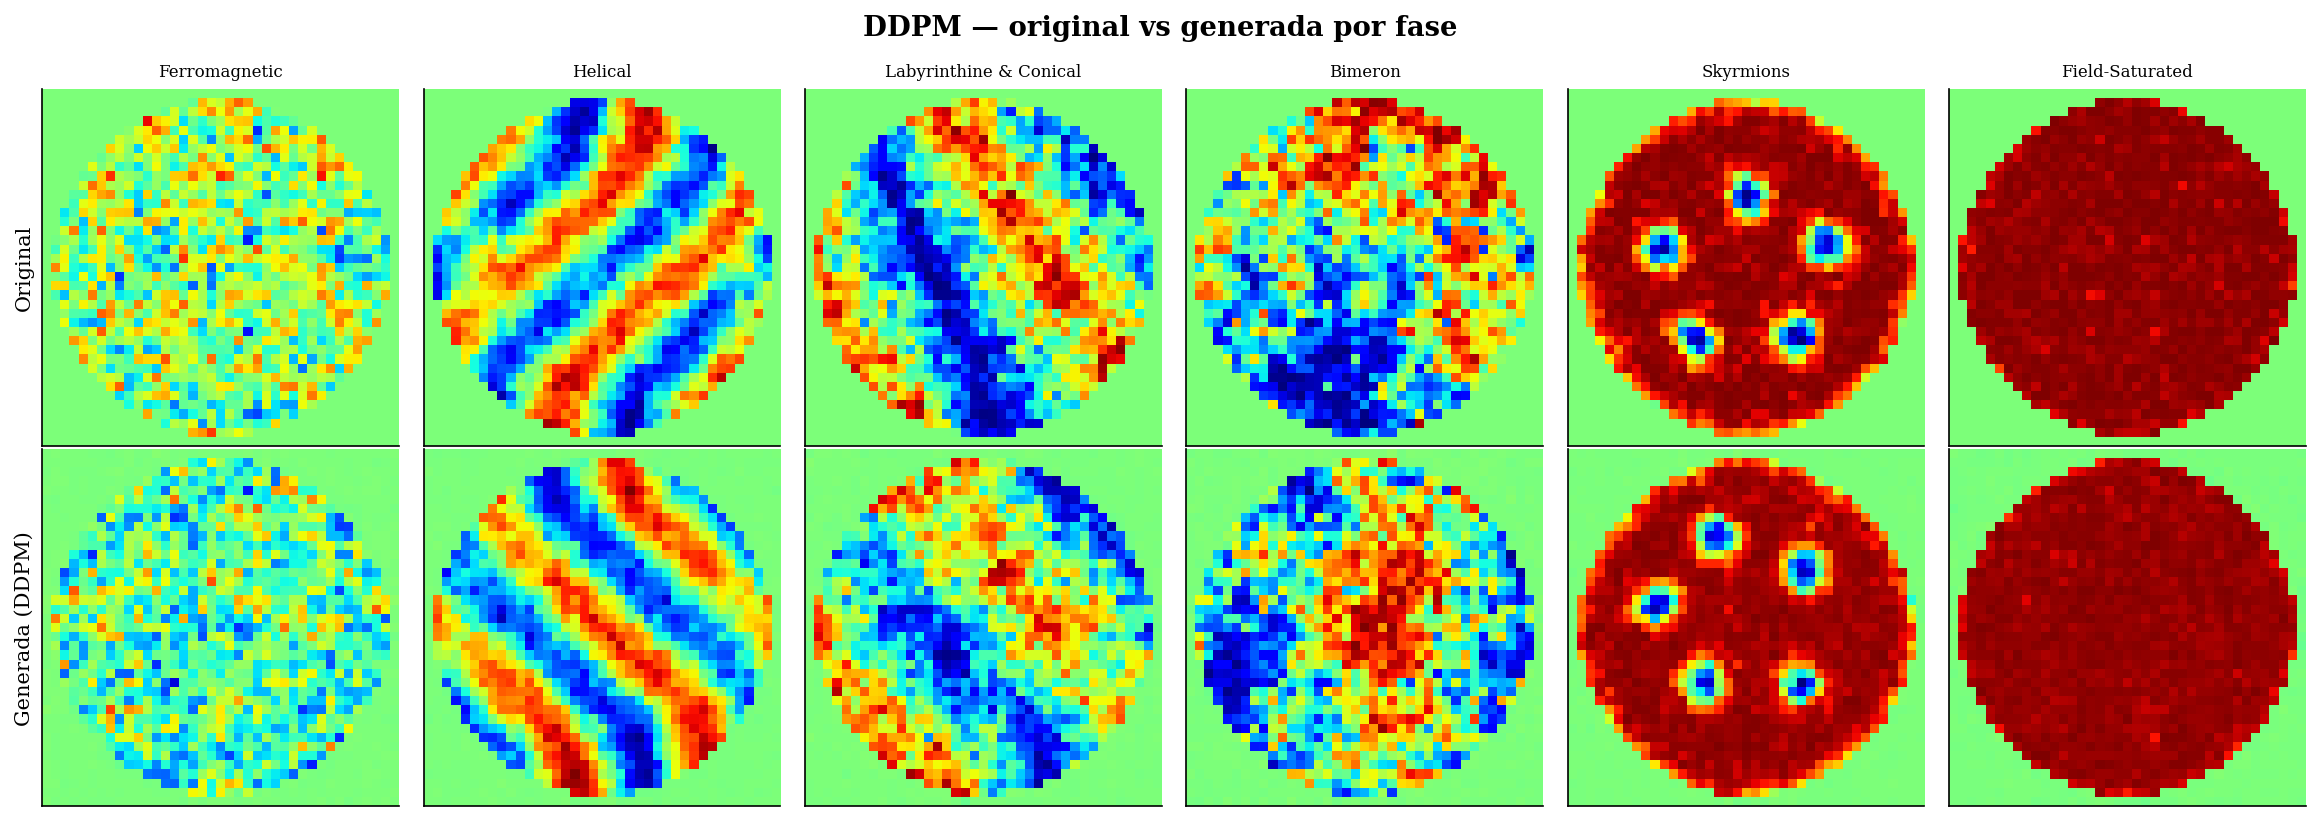

Listo. Revisa que las métricas físicas tengan rangos razonables y coherentes por fase.


In [14]:
# ============================================================
# Sanity visual: original vs generada (crop 39) por fase
# ============================================================
n_cols = len(phases)
fig, axes = plt.subplots(2, n_cols, figsize=(2.6 * n_cols, 5.6))
vis_rng = np.random.RandomState(SAMPLE_SEED)
for c, ph in enumerate(phases):
    idx_ph = np.where(eval_phase == ph)[0]
    pick = vis_rng.choice(idx_ph)
    cond_one = torch.from_numpy(eval_cond[pick:pick+1]).to(DEVICE)
    gen40 = fast_sample(model, cond_one, scheduler, n_steps=FAST_STEPS, img_size=IMG_SIZE)
    gen39 = gen40[0, 0, :CROP_TO, :CROP_TO].cpu().numpy()
    real39 = eval_imgs[pick, :, :, 0]
    axes[0, c].imshow(real39, cmap="jet", vmin=-1, vmax=1); axes[0, c].set_title(ph, fontsize=8)
    axes[1, c].imshow(gen39, cmap="jet", vmin=-1, vmax=1)
    for r in range(2):
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Generada (DDPM)", fontsize=10)
fig.suptitle("DDPM — original vs generada por fase", fontweight="bold")
plt.tight_layout()
plt.savefig("ddpm_visual_by_phase.png", dpi=120)
plt.show()
print("Listo. Revisa que las métricas físicas tengan rangos razonables y coherentes por fase.")